In [11]:
pip install matplotlib

   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/7.8 MB 10.1 MB/s eta 0:00:01
   ------------------------------------- -- 7.3/7.8 MB 23.8 MB/s eta 0:00:01
   ---------------------------------------- 7.8/7.8 MB 21.1 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 3.20.3 which is incompatible.


In [4]:
import os

print(os.listdir('dataset'))

['kaggle_3m', 'lgg-mri-segmentation']


In [5]:
import os

for root, dirs, files in os.walk('dataset'):
    print(root)
    break

dataset


In [6]:
import os

for root, dirs, files in os.walk('dataset'):
    print(root)

dataset
dataset\kaggle_3m
dataset\kaggle_3m\TCGA_CS_4941_19960909
dataset\kaggle_3m\TCGA_CS_4942_19970222
dataset\kaggle_3m\TCGA_CS_4943_20000902
dataset\kaggle_3m\TCGA_CS_4944_20010208
dataset\kaggle_3m\TCGA_CS_5393_19990606
dataset\kaggle_3m\TCGA_CS_5395_19981004
dataset\kaggle_3m\TCGA_CS_5396_20010302
dataset\kaggle_3m\TCGA_CS_5397_20010315
dataset\kaggle_3m\TCGA_CS_6186_20000601
dataset\kaggle_3m\TCGA_CS_6188_20010812
dataset\kaggle_3m\TCGA_CS_6290_20000917
dataset\kaggle_3m\TCGA_CS_6665_20010817
dataset\kaggle_3m\TCGA_CS_6666_20011109
dataset\kaggle_3m\TCGA_CS_6667_20011105
dataset\kaggle_3m\TCGA_CS_6668_20011025
dataset\kaggle_3m\TCGA_CS_6669_20020102
dataset\kaggle_3m\TCGA_DU_5849_19950405
dataset\kaggle_3m\TCGA_DU_5851_19950428
dataset\kaggle_3m\TCGA_DU_5852_19950709
dataset\kaggle_3m\TCGA_DU_5853_19950823
dataset\kaggle_3m\TCGA_DU_5854_19951104
dataset\kaggle_3m\TCGA_DU_5855_19951217
dataset\kaggle_3m\TCGA_DU_5871_19941206
dataset\kaggle_3m\TCGA_DU_5872_19950223
dataset\kaggle

In [7]:
from glob import glob

mask_paths = glob("dataset/**/*mask*.*", recursive=True)

print("Number of masks found:", len(mask_paths))
print(mask_paths[:5])

Number of masks found: 7858
['dataset\\kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_10_mask.tif', 'dataset\\kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_11_mask.tif', 'dataset\\kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_12_mask.tif', 'dataset\\kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_13_mask.tif', 'dataset\\kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_14_mask.tif']


In [8]:
pairs = []

for mask_path in mask_paths:
    image_path = mask_path.replace("_mask", "")
    pairs.append((image_path, mask_path))

print("Total image-mask pairs:", len(pairs))
print("\nSample pair:")
print("Image:", pairs[0][0])
print("Mask :", pairs[0][1])

Total image-mask pairs: 7858

Sample pair:
Image: dataset\kaggle_3m\TCGA_CS_4941_19960909\TCGA_CS_4941_19960909_10.tif
Mask : dataset\kaggle_3m\TCGA_CS_4941_19960909\TCGA_CS_4941_19960909_10_mask.tif


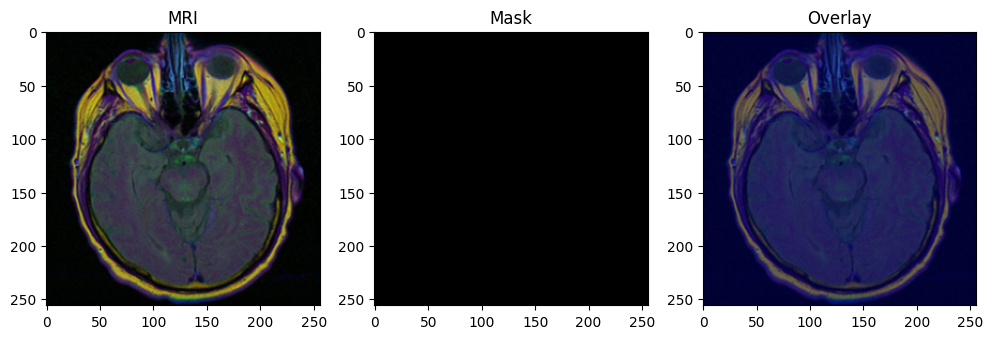

In [9]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(pairs[0][0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(pairs[0][1], 0)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.subplot(1,3,3)
plt.imshow(img)
plt.imshow(mask, alpha=0.4, cmap='jet')
plt.title("Overlay")

plt.show()

In [10]:
import numpy as np
import cv2

IMG_SIZE = 128

X = []
Y = []

for img_path, mask_path in pairs:

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    mask = cv2.imread(mask_path, 0)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    X.append(img / 255.0)
    Y.append(mask / 255.0)

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

Y = np.expand_dims(Y, axis=-1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (7858, 128, 128, 3)
Y shape: (7858, 128, 128, 1)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Training images:", X_train.shape)
print("Testing images :", X_test.shape)

Training images: (6286, 128, 128, 3)
Testing images : (1572, 128, 128, 3)


In [12]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices())

2.10.1
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (6286, 128, 128, 3)
X_test : (1572, 128, 128, 3)
y_train: (6286, 128, 128, 1)
y_test : (1572, 128, 128, 1)


In [14]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

def unet():

    inputs = Input((128,128,3))

    # Encoder
    c1 = Conv2D(16,3,activation='relu',padding='same')(inputs)
    c1 = Conv2D(16,3,activation='relu',padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(32,3,activation='relu',padding='same')(p1)
    c2 = Conv2D(32,3,activation='relu',padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(64,3,activation='relu',padding='same')(p2)
    c3 = Conv2D(64,3,activation='relu',padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    # Bottleneck
    bn = Conv2D(128,3,activation='relu',padding='same')(p3)

    # Decoder
    u1 = UpSampling2D()(bn)
    u1 = concatenate([u1,c3])

    c4 = Conv2D(64,3,activation='relu',padding='same')(u1)

    u2 = UpSampling2D()(c4)
    u2 = concatenate([u2,c2])

    c5 = Conv2D(32,3,activation='relu',padding='same')(u2)

    u3 = UpSampling2D()(c5)
    u3 = concatenate([u3,c1])

    c6 = Conv2D(16,3,activation='relu',padding='same')(u3)

    outputs = Conv2D(1,1,activation='sigmoid')(c6)

    model = Model(inputs,outputs)

    return model

In [15]:
model = unet()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 128, 128, 16  448         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 128, 128, 16  2320        ['conv2d[0][0]']                 
                                )                                                             

In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=3,
    batch_size=8
)

Epoch 1/3
708/708 [==============================] - 492s 692ms/step - loss: 0.0381 - accuracy: 0.9886 - val_loss: 0.0226 - val_accuracy: 0.9921
Epoch 2/3
708/708 [==============================] - 494s 697ms/step - loss: 0.0208 - accuracy: 0.9929 - val_loss: 0.0183 - val_accuracy: 0.9937
Epoch 3/3
708/708 [==============================] - 595s 841ms/step - loss: 0.0166 - accuracy: 0.9939 - val_loss: 0.0149 - val_accuracy: 0.9944


In [18]:
preds = model.predict(X_test)

50/50 [==============================] - 34s 666ms/step


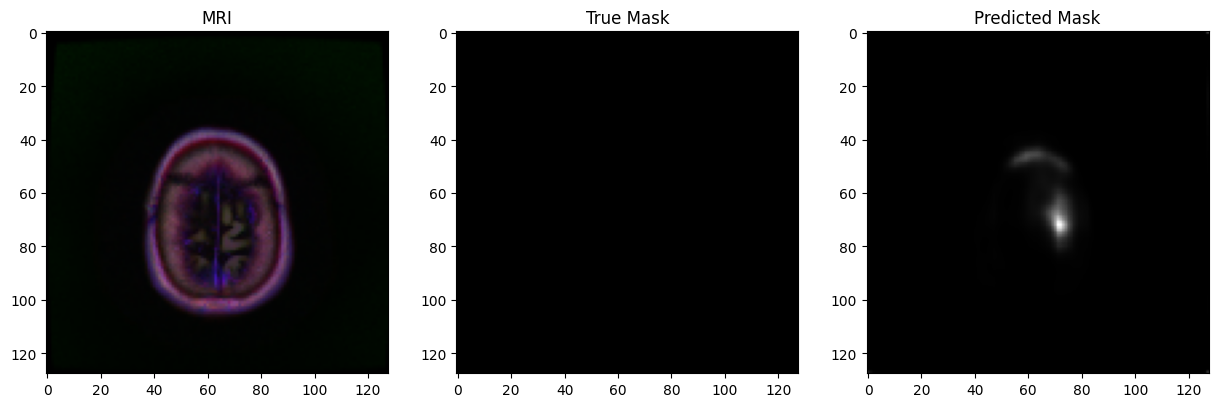

In [19]:
import matplotlib.pyplot as plt

idx = 5

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(X_test[idx])
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(y_test[idx].squeeze(), cmap='gray')
plt.title("True Mask")

plt.subplot(1,3,3)
plt.imshow(preds[idx].squeeze(), cmap='gray')
plt.title("Predicted Mask")

plt.show()

In [20]:
import tensorflow as tf

def dice_coef(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.keras.backend.sum(y_true * y_pred)

    return (2. * intersection + 1) / (
        tf.keras.backend.sum(y_true) +
        tf.keras.backend.sum(y_pred) + 1
    )

In [21]:
results = model.evaluate(X_test, y_test)

print(results)

50/50 [==============================] - 23s 456ms/step - loss: 0.0166 - accuracy: 0.9939
[0.01660984754562378, 0.9938652515411377]


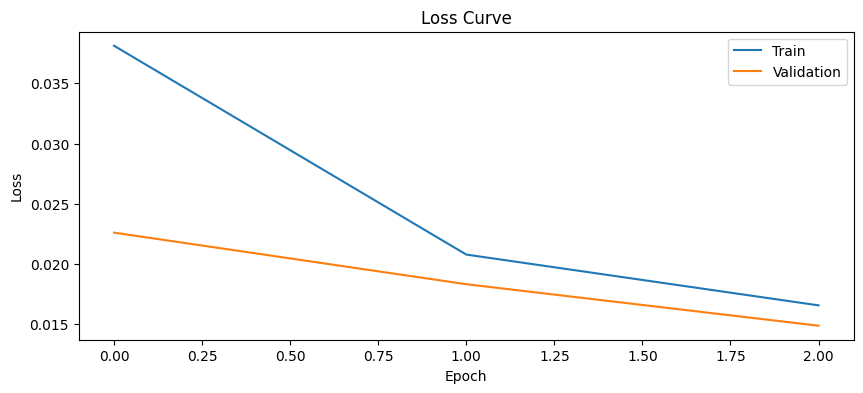

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

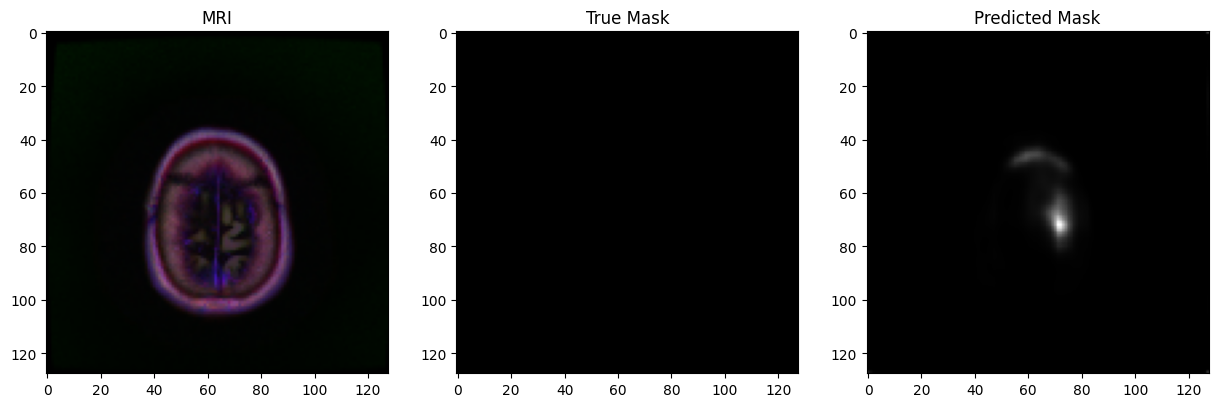

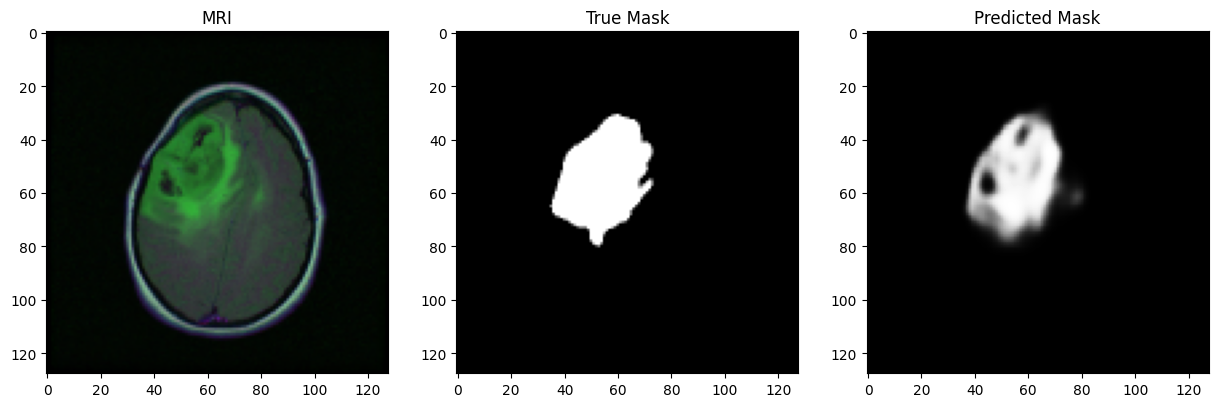

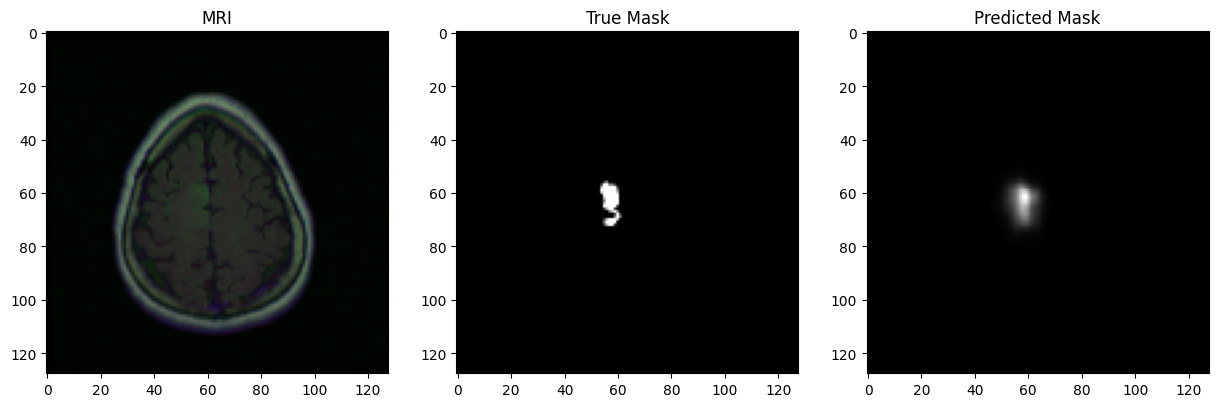

In [23]:
for idx in [5, 20, 50]:

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(X_test[idx])
    plt.title("MRI")

    plt.subplot(1,3,2)
    plt.imshow(y_test[idx].squeeze(), cmap='gray')
    plt.title("True Mask")

    plt.subplot(1,3,3)
    plt.imshow(preds[idx].squeeze(), cmap='gray')
    plt.title("Predicted Mask")

    plt.show()

In [24]:
import tensorflow as tf

def dice_coef(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.keras.backend.sum(y_true * y_pred)

    return (2. * intersection + 1) / (
        tf.keras.backend.sum(y_true)
        + tf.keras.backend.sum(y_pred)
        + 1
    )

In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coef]
)

In [26]:
model.fit(
    X_train,
    y_train,
    epochs=1,
    batch_size=8
)

786/786 [==============================] - 768s 974ms/step - loss: 0.0132 - accuracy: 0.9947 - dice_coef: 0.5751


In [27]:
def iou(y_true, y_pred):

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.keras.backend.sum(y_true * y_pred)

    union = (
        tf.keras.backend.sum(y_true)
        + tf.keras.backend.sum(y_pred)
        - intersection
    )

    return (intersection + 1) / (union + 1)

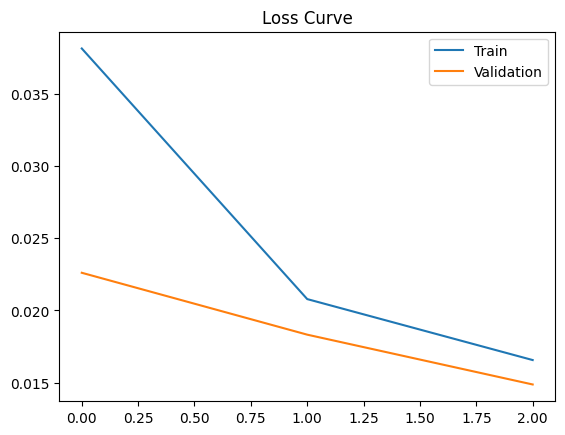

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])
plt.title('Loss Curve')
plt.show()

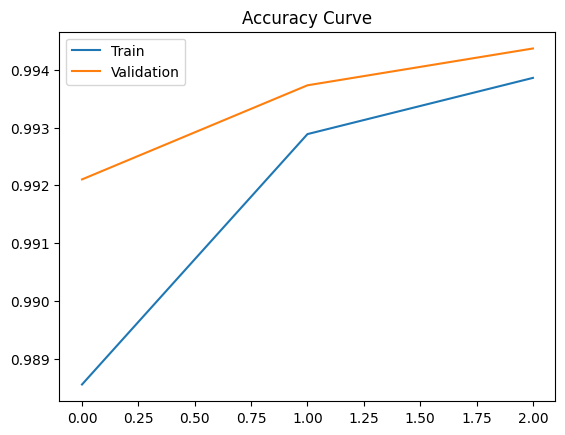

In [29]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])
plt.title('Accuracy Curve')
plt.show()

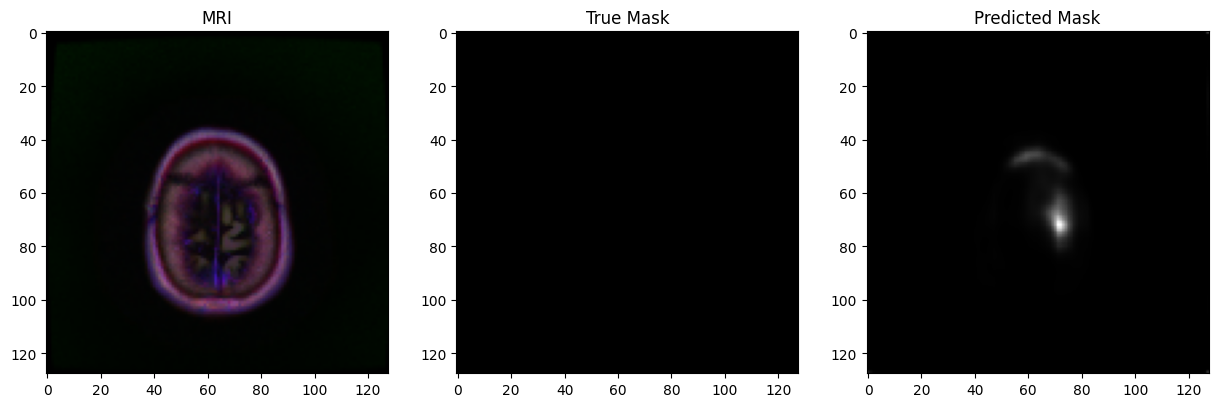

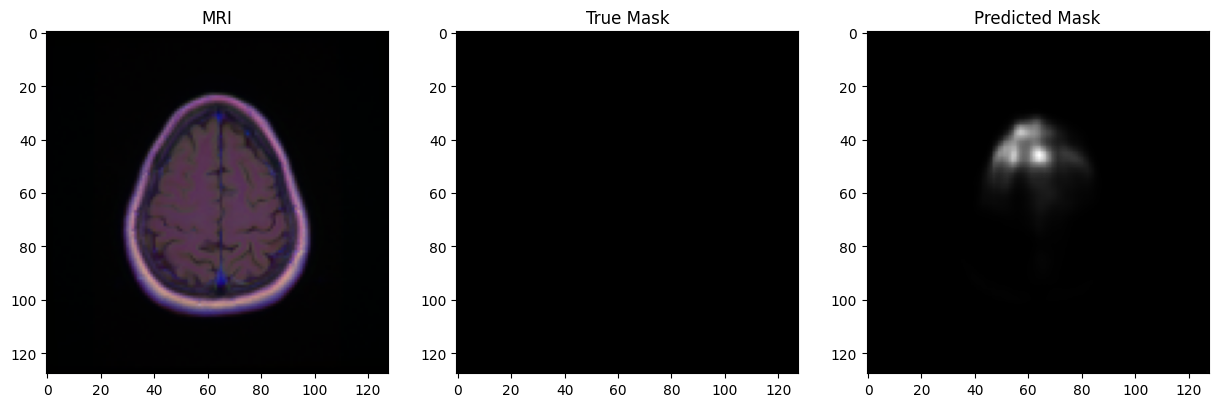

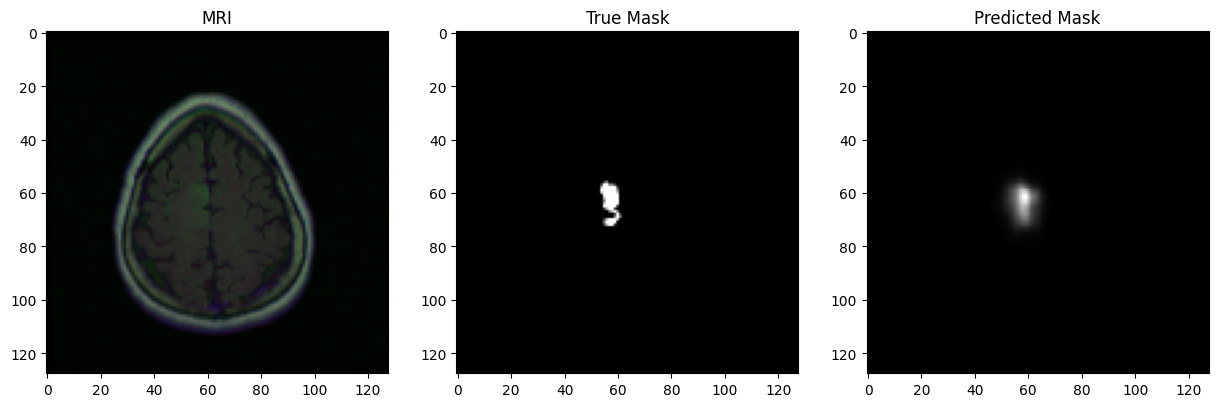

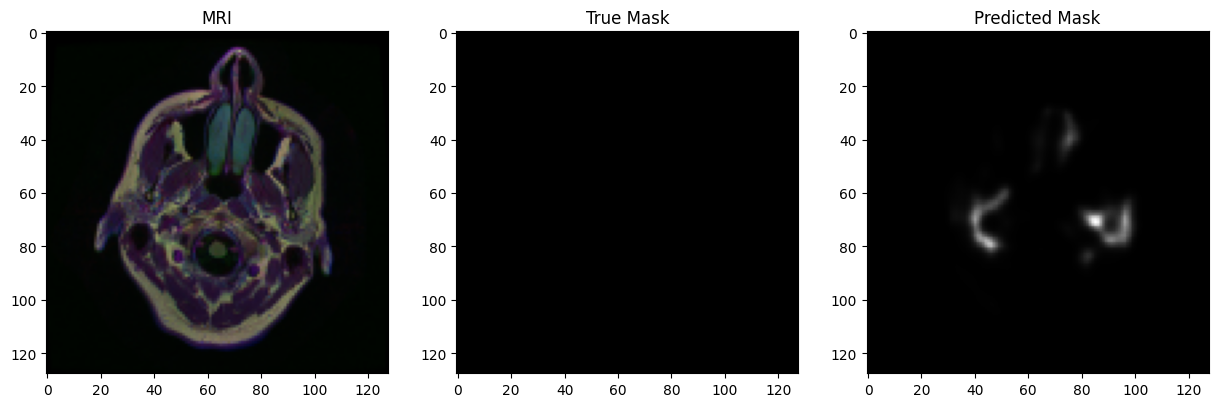

In [30]:
import matplotlib.pyplot as plt

for idx in [5, 25, 50, 100]:

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(X_test[idx])
    plt.title("MRI")

    plt.subplot(1,3,2)
    plt.imshow(y_test[idx].squeeze(), cmap='gray')
    plt.title("True Mask")

    plt.subplot(1,3,3)
    plt.imshow(preds[idx].squeeze(), cmap='gray')
    plt.title("Predicted Mask")

    plt.show()